<a href="https://colab.research.google.com/github/JuanGallo132/sprint9-final-proyecto-8-A-B-Testing-Landing-Page-Experiment/blob/main/FINAL_S9_Version_Student_Proyecto_Landing_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import FileLink
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

In [ ]:
# Descarga del archivo CSV
# Primero lo guardamos en el entorno local de la sesión
file_name = 'landing_experiment.csv'
df.to_csv(file_name, index=False)

# Generamos el link de descarga
print("Haz clic en el enlace para descargar:")
FileLink(file_name)

Haz clic en el enlace para descargar:


/app/landing_experiment.csv

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


In [ ]:
# Convertir columna date a tipo de dato de fecha
df['date'] = pd.to_datetime(df['date'])

# Verificar conversión
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  int64         
 8   gasto           40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB


* El dataframe consta de 40,000 registros
* No se encuntran valores nulos en ninguna columna
* Se encuentra que la columjna date en el DataFrame original es de tipo object, por lo cual se realiza una conversión de tipo de dato a Datetime

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
# Verificación de usuarios únicos
df['user_id'].nunique()

40000

In [ ]:
# Verificación de usuarios duplicados
df['user_id'].duplicated().sum()

0

Con base en las anteriores verificaciones se constata la existencia de úsuarios únicos y, por tanto, sin duplicados en la base de datos.

 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df['converted'].describe()

count    40000.00000
mean         0.14265
std          0.34972
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
Name: converted, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("\n========== CONTEO DE CATEGORÍAS ==========\n")

columnas_categoricas = ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']

for col in columnas_categoricas:
    print(f"\n--- Columna: {col} ---")

    if col in df.columns:
        conteo = df[col].value_counts(dropna = False)
        porcentaje = df[col].value_counts(normalize = True, dropna = False) * 100

        resumen = pd.DataFrame({
            "Conteo": conteo,
            "Porcentaje (%)": porcentaje.round(2)
        })

        print(resumen)
        print(f"\nTotal únicos: {df[col].nunique(dropna=False)}")
    else:
        print("⚠️ La columna no existe en el DataFrame.")


========== CONTEO DE CATEGORÍAS ==========


--- Columna: landing ---
   Conteo  Porcentaje (%)
B   20018           50.04
A   19982           49.96

Total únicos: 2

--- Columna: region ---
           Conteo  Porcentaje (%)
Norte       11166           27.92
Centro       9613           24.03
Sur          8039           20.10
Occidente    6398           16.00
Oriente      4784           11.96

Total únicos: 5

--- Columna: dispositivo ---
         Conteo  Porcentaje (%)
Mobile    24829           62.07
Desktop   15171           37.93

Total únicos: 2

--- Columna: traffic_source ---
          Conteo  Porcentaje (%)
Organic    17987           44.97
Ads        11935           29.84
Email       6123           15.31
Referral    3955            9.89

Total únicos: 4

--- Columna: user_type ---
            Conteo  Porcentaje (%)
Nuevo        26033           65.08
Recurrente   13967           34.92

Total únicos: 2


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[df['landing'] == 'A']['gasto']
gasto_B = df[df['landing'] == 'B']['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(19982, 20018)

### Prueba t para variables numéricas

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una diferencia estadísticamente significativa entre el gasto promedio de los usuarios de la página A y la página B. Matemáticamente: $\mu_A = \mu_B$.
- **Hipótesis alternativa (H₁):** Existe una diferencia estadísticamente significativa entre el gasto promedio de los usuarios de la página A y la página B. Matemáticamente: $\mu_A \neq \mu_B$.

In [ ]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico t: {t_stat}")
print(f"Valor p: {p_value}")

# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Estadístico t: -12.84131999696572
Valor p: 1.142258400461568e-37
Rechazamos la hipótesis nula: hay evidencia de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  
Tras ejecutar la prueba T de muestras independientes para comparar el gasto promedio entre la Página A y la Página B, se obtuvo un valor p de $1.14 \times 10^{-37}$. Dado que este valor es significativamente inferior al umbral de significancia establecido ($\alpha = 0.05$), existe evidencia estadística suficiente para rechazar la hipótesis nula. Por lo tanto, se confirma con un 95% de confianza que existe una diferencia estadísticamente significativa en el comportamiento de gasto entre ambos grupos.

**Interpretación de negocio:**  
Los datos confirman que el cambio realizado entre una página y otra no es producto del azar, sino que responde a una diferencia real en la propensión de gasto de los usuarios. El estadístico $t$ de -12.84 sugiere que hay una disparidad marcada en el volumen de compra. Desde una perspectiva comercial, esto significa que:
* Validación de Estrategia: El diseño o la funcionalidad de la página que presenta el promedio más alto (presumiblemente la B, dado el signo negativo del estadístico) es superior para impulsar las ventas.
* Impacto en Ingresos: No se trata de una variación diaria común; hemos encontrado una 'palanca' que mueve la aguja del negocio de manera consistente.
* Recomendación: Se recomienda escalar la versión ganadora a todo el tráfico, ya que los resultados son lo suficientemente robustos como para garantizar un retorno de inversión similar en el futuro.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una diferencia estadísticamente significativa entre la tasa de conversión de la página A y la tasa de conversión de la página B ($CR_A = CR_B$). Cualquier variación observada se debe al azar.
- **Hipótesis alternativa (H₁):** Existe una diferencia estadísticamente significativa entre la tasa de conversión de la página A y la página B ($CR_A \neq CR_B$), lo que indica que una de las versiones es más efectiva que la otra para convertir usuarios.

In [ ]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [ ]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(conversiones, totales)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22
Rechazamos la hipótesis nula: hay evidencia de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  
Con un valor p de $3.76 \times 10^{-22}$, el cual es significativamente menor al nivel de significancia establecido ($\alpha = 0.05$), se procede a rechazar la hipótesis nula. Existe evidencia estadística contundente para afirmar que las tasas de conversión de la página A y la página B no son iguales.

**Interpretación de negocio:**  
Los resultados demuestran que el diseño de la página tiene un impacto real y medible en la capacidad de convertir usuarios en clientes. Esta diferencia no es producto del azar o de fluctuaciones temporales de tráfico, sino que responde a una mejora en la efectividad del embudo de ventas en una de las versiones.

Desde una perspectiva estratégica, esto implica:
* Optimización del ROAS: La versión con mayor tasa de conversión permite reducir el costo de adquisición por cliente (CAC).
* Escalabilidad: Se recomienda implementar la variante ganadora de forma definitiva, ya que garantiza una mayor eficiencia en la generación de volumen de usuarios convertidos.
* Significancia Práctica: Dado que el estadístico Z es de -9.67, la magnitud de la diferencia es lo suficientemente amplia como para justificar una transición inmediata hacia la página con mejor rendimiento.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba chi cuadrado

**Hipótesis:**
- **Hipótesis nula (H₀):** La fuente de tráfico y la conversión son variables independientes. No existe una asociación significativa entre el canal de origen del usuario y su probabilidad de convertir.
- **Hipótesis alternativa (H₁):** La fuente de tráfico y la conversión son variables dependientes. Existe una asociación estadísticamente significativa, lo que sugiere que ciertos canales generan conversiones con mayor efectividad que otros.

In [ ]:
# Construir tabla de contingencia
tabla = pd.crosstab(df['traffic_source'], df['converted'])

# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")

# Intepretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

print() #salto de línea

# Tabla de contingencia normalizada

print(pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100)


Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Rechazamos la hipótesis nula: hay evidencia de una diferencia.

converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163


### 📝 Conclusión e interpretación

**Decisión:**  
Con un valor P de 0.034, el cual se sitúa por debajo del umbral de significancia estándar ($\alpha = 0.05$), se toma la decisión estadística de rechazar la hipótesis nula. Esto confirma que existe una asociación estadísticamente significativa entre la fuente de tráfico y el estado de conversión de los usuarios.

**Interpretación de negocio:**  
Los resultados indican que el canal por el cual un usuario llega a la plataforma influye directamente en su probabilidad de convertirse en cliente. No todas las fuentes de tráfico tienen el mismo rendimiento, lo que permite una optimización estratégica del presupuesto de marketing.

Observando las tasas de conversión por canal:
* Canal con mejor desempeño: El tráfico proveniente de Email presenta la tasa de conversión más alta con un 14.99%.
* Canal secundario: Los anuncios (Ads) muestran un rendimiento sólido del 14.73%.
* Canales con menor eficiencia: El tráfico Orgánico (13.78%) y de Referidos (13.88%) registran las tasas de conversión más bajas del experimento.

Recomendaciones estratégicas:
* Priorización de Inversión: Se recomienda asignar mayor presupuesto o esfuerzos de campaña al canal de Email, ya que ha demostrado ser el más efectivo para movilizar a los usuarios hacia la conversión.
* Revisión de Canales Orgánicos: Es necesario analizar por qué el tráfico orgánico y de referidos está convirtiendo a un ritmo inferior, con el fin de ajustar el contenido o la segmentación en estas fuentes.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba chi cuadrado

**Hipótesis:**
- **Hipótesis nula (H₀):** El tipo de usuario y la conversión son variables independientes. Ser un usuario nuevo o recurrente no afecta significativamente la probabilidad de conversión.
- **Hipótesis alternativa (H₁):** El tipo de usuario y la conversión son variables dependientes. Existe una asociación significativa que indica que ciertos perfiles de usuario muestran una mayor propensión a la conversión.

In [ ]:
# Construir tabla de contingencia
tabla = pd.crosstab(df['user_type'], df['converted'])

# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")

# Intepretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

print() #salto de línea

# Tabla de contingencia normalizada

print(pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100)


Estadístico chi-cuadrado: 0.513
Valor P: 0.474
No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.

converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


### 📝 Conclusión e interpretación

**Decisión:**  
Con un valor P de 0.474, el cual es notablemente superior al nivel de significancia establecido ($\alpha = 0.05$), se determina que no existe evidencia estadística suficiente para rechazar la hipótesis nula. Por consiguiente, se concluye que el tipo de usuario y el estado de conversión son variables independientes en este conjunto de datos.

**Interpretación de negocio:**  
Los resultados indican que la probabilidad de conversión no depende de si el visitante es un usuario nuevo o uno recurrente. La paridad en el comportamiento sugiere que la propuesta de valor y el diseño de la página están impactando de manera uniforme a ambos segmentos de la audiencia.

Al analizar las métricas específicas:
* Usuarios Nuevos: Registran una tasa de conversión del 14.36%.
* Usuarios Recurrentes: Presentan una tasa de conversión del 14.09%.
* Hallazgo clave: La diferencia de apenas 0.27 puntos porcentuales es estadísticamente insignificante y debe tratarse como ruido aleatorio dentro de la muestra.

Implicaciones estratégicas:
* Consistencia de Mensaje: No es necesario, por el momento, crear flujos de conversión drásticamente diferentes o personalizados según la recurrencia del usuario, ya que ambos grupos responden de forma similar a la interfaz actual.
* Enfoque de Optimización: Dado que el tipo de usuario no es un factor determinante para la conversión, los esfuerzos de optimización deben centrarse en variables que sí mostraron impacto, como la fuente de tráfico o el diseño de la página (A/B).

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

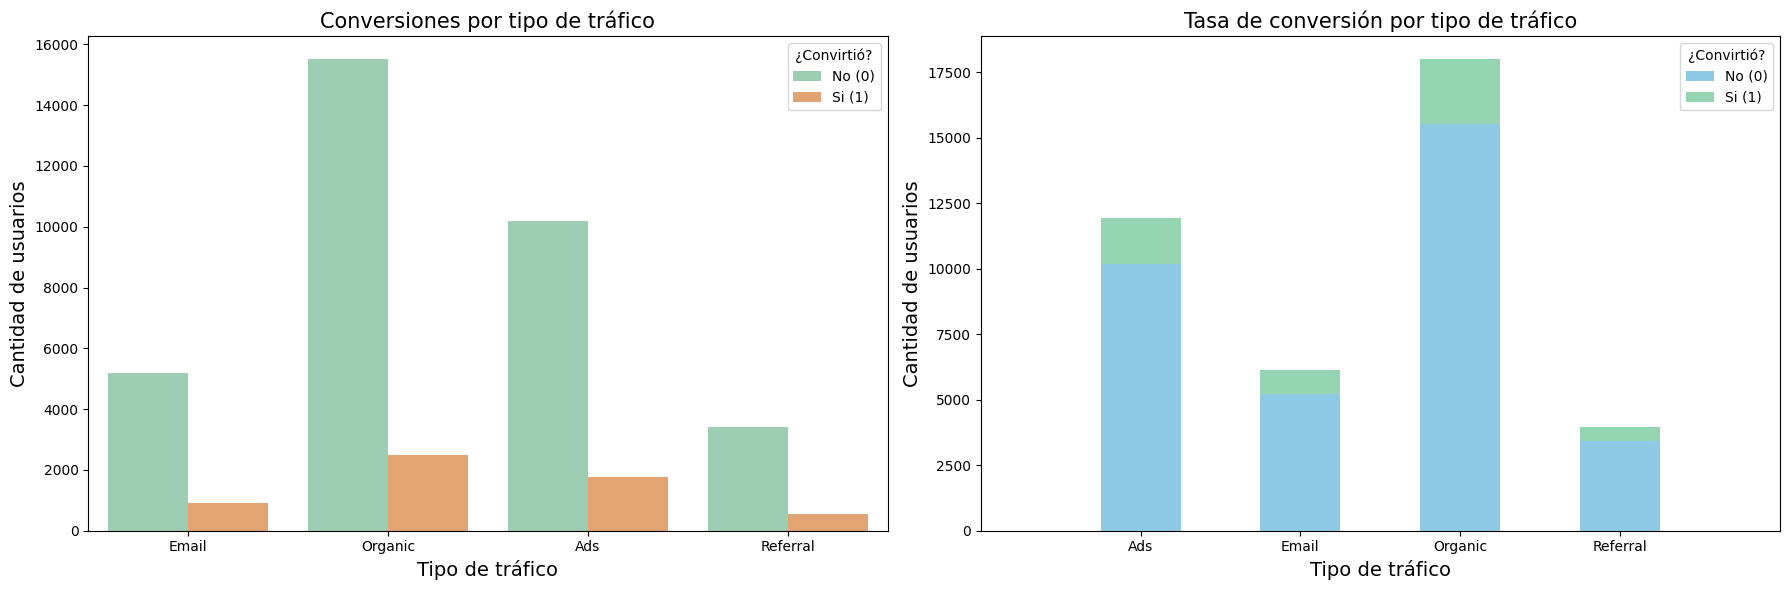

In [ ]:
# Nuevamente se realiza la tabla de contingencia para los gráficos de esta sección en específico
tabla_traffic_source = pd.crosstab(df['traffic_source'], df['converted'])

# Nuevamente se realiza la prueba chi2 para los gráficos de esta sección en específico
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_traffic_source)

fig, axes = plt.subplots(1, 2, figsize = (18, 6))

# Gráfico de barras agrupadas
sns.countplot(data = df, x = 'traffic_source', hue = 'converted', palette = ['#95D5B2', '#F4A261'], ax = axes[0])
axes[0].set_title('Conversiones por tipo de tráfico', fontsize = 15)
axes[0].set_xlabel('Tipo de tráfico', fontsize = 14)
axes[0].set_ylabel('Cantidad de usuarios', fontsize = 14)
axes[0].legend(title = '¿Convirtió?', labels = ['No (0)', 'Si (1)'])

# Gráfico de barras apiladas
tabla_traffic_source.plot(kind = 'bar', stacked = True, color = ["#8ECAE6", "#95D5B2"], ax = axes[1])
axes[1].set_title('Tasa de conversión por tipo de tráfico', fontsize = 15)
axes[1].set_xlabel('Tipo de tráfico', fontsize = 14)
axes[1].set_ylabel('Cantidad de usuarios', fontsize = 14)
axes[1].set_xlim(-1, 4)
axes[1].legend(title = '¿Convirtió?', labels = ['No (0)', 'Si (1)'])
axes[1].tick_params(axis = 'x', rotation = 0)

plt.tight_layout()
plt.show()

1. Dominio del Tráfico Orgánico en Volumen
* Mayor alcance: El canal Organic es, por mucho, el que atrae a la mayor cantidad de usuarios totales al sitio.
* Mayor número de conversiones brutas: Debido a su alto volumen, también es el canal que genera la mayor cantidad absoluta de usuarios convertidos (barras naranjas en el primer gráfico).

2. Eficacia vs. Volumen (Tasa de Conversión)
* Canales de alta intención: Aunque el Email tiene un volumen de usuarios mucho menor que el Orgánico, visualmente muestra una proporción de conversión (segmento verde en el gráfico de tasas) muy competitiva.
* Rendimiento de Ads: Los anuncios (Ads) mantienen un equilibrio sólido; son el segundo canal en volumen de tráfico y mantienen una tasa de conversión visiblemente saludable, superando en eficiencia proporcional al tráfico de Referidos.

3. Áreas de Oportunidad
* Bajo rendimiento de Referral: El tráfico de Referral no solo es el más bajo en volumen, sino que también muestra la menor proporción de éxito en su tasa de conversión. Esto sugiere que las fuentes externas actuales no están enviando tráfico calificado.
* Potencial del Email: Dado que el Email convierte bien pero tiene poco volumen, hay una oportunidad clara de crecimiento si se logra aumentar la base de contactos o la frecuencia de envíos, ya que su "calidad" de usuario es alta.

### Relación entre el tipo de usuario y la conversión

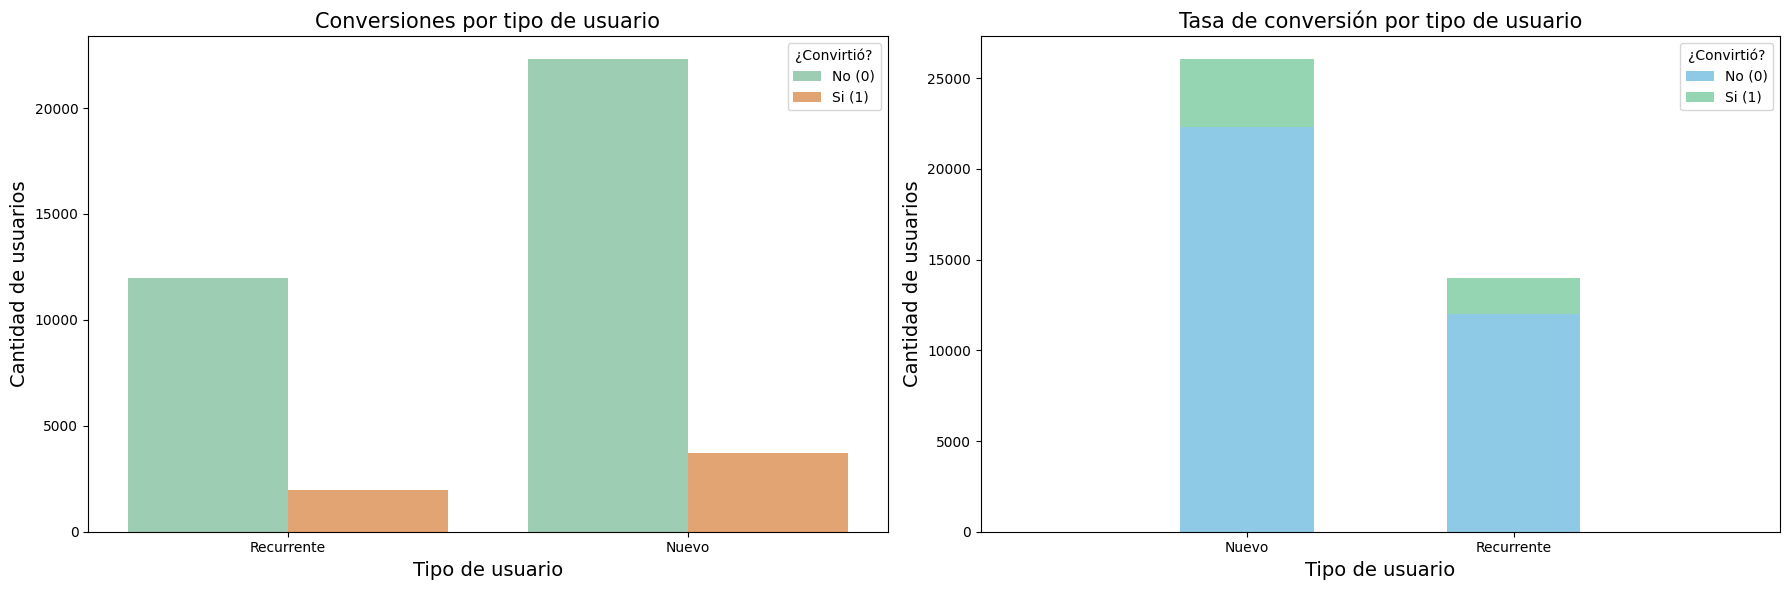

In [ ]:
# Nuevamente se realiza la tabla de contingencia para los gráficos de esta sección en específico
tabla_user_type = pd.crosstab(df['user_type'], df['converted'])

# Nuevamente se realiza la prueba chi2 para los gráficos de esta sección en específico
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_user_type)

fig, axes = plt.subplots(1, 2, figsize = (18, 6))

# Gráfico de barras agrupadas
sns.countplot(data = df, x = 'user_type', hue = 'converted', palette = ['#95D5B2', '#F4A261'], ax = axes[0])
axes[0].set_title('Conversiones por tipo de usuario', fontsize = 15)
axes[0].set_xlabel('Tipo de usuario', fontsize = 14)
axes[0].set_ylabel('Cantidad de usuarios', fontsize = 14)
axes[0].legend(title = '¿Convirtió?', labels = ['No (0)', 'Si (1)'])

# Gráfico de barras apiladas
tabla_user_type.plot(kind = 'bar', stacked = True, color = ["#8ECAE6", "#95D5B2"], ax = axes[1])
axes[1].set_title('Tasa de conversión por tipo de usuario', fontsize = 15)
axes[1].set_xlabel('Tipo de usuario', fontsize = 14)
axes[1].set_ylabel('Cantidad de usuarios', fontsize = 14)
axes[1].set_xlim(-1, 2)
axes[1].legend(title = '¿Convirtió?', labels = ['No (0)', 'Si (1)'])
axes[1].tick_params(axis = 'x', rotation = 0)

plt.tight_layout()
plt.show()

1. Dominio de Usuarios Nuevos en Volumen
* Adquisición activa: La plataforma atrae a una cantidad significativamente mayor de usuarios nuevos en comparación con los recurrentes.
* Impacto en conversiones totales: Debido a este alto volumen, el mayor número absoluto de conversiones proviene de los usuarios que visitan el sitio por primera vez (barras naranjas en el primer gráfico).

2. Homogeneidad en la Tasa de Conversión
* Comportamiento similar: Al observar el gráfico de Tasa de conversión por tipo de usuario, se nota que la proporción de usuarios que convierten (segmentos verdes) es visualmente muy parecida en ambos grupos.
* Consistencia del embudo: Esto sugiere que la experiencia de usuario y la propuesta de valor son igualmente efectivas tanto para convencer a alguien que no conoce la marca como para alguien que ya la ha visitado.

3. Comentarios Estratégicos
* Escalabilidad: Dado que los usuarios nuevos convierten a una tasa saludable y similar a los recurrentes, el negocio tiene un gran potencial de crecimiento simplemente aumentando la inversión en captación de tráfico.
* Retención: Aunque el volumen de usuarios recurrentes es menor, el hecho de que su tasa de conversión no sea drásticamente superior a la de los nuevos indica que no existe una dependencia crítica de la "lealtad" para generar ventas; el sitio es eficiente "al primer contacto".

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
* La prueba t arrojó un valor p extremadamente bajo (1.14 × 10⁻³⁷), lo que indica una diferencia estadísticamente significativa entre el gasto promedio de la versión A y la versión B.
* La versión B presenta un gasto promedio superior frente a la versión A. <br><br>
**Interpretación:** <br> La versión B no solo convierte, sino que además genera mayor valor económico por usuario convertido. Desde una perspectiva de ingresos, la página B es más rentable.

**Tasa de conversión:**
* La prueba Z mostró un valor p de 3.76 × 10⁻²², evidenciando una diferencia estadísticamente significativa en la tasa de conversión.
* La versión B presenta una tasa de conversión mayor que la versión A. <br><br>
**Interpretación:** <br> La página B no solo monetiza mejor, sino que también convierte a un mayor porcentaje de usuarios. Esto la posiciona como la opción óptima tanto en volumen como en eficiencia comercial.

---

#### 📊 **Segmentación por fuente de tráfico**
- Existe asociación estadísticamente significativa entre la fuente de tráfico y la conversión (p = 0.034).
- El tráfico orgánico domina en volumen y genera la mayor cantidad absoluta de conversiones. <br><br>
**Interpretación:** <br> No todos los canales convierten igual. Se recomienda optimizar inversión en los canales con mayor tasa de conversión, no solo en los de mayor volumen.

 ---

#### 📊 **Segmentación por tipo de usuario**
- No se encontró relación estadísticamente significativa entre tipo de usuario y conversión (p = 0.474). <br><br>
**Interpretación:** <br> Ser usuario nuevo o recurrente no afecta significativamente la probabilidad de conversión. La estrategia puede enfocarse más en optimizar la experiencia general que en segmentar por recurrencia.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:**
- Implementar la versión B como versión oficial.
- Priorizar optimización y escalamiento de los canales de tráfico con mejor desempeño relativo.
- Mantener monitoreo continuo del gasto promedio y tasa de conversión.
- Realizar futuras pruebas enfocadas en personalización por canal más que por tipo de usuario.
<h3> En términos de negocio: </h3>
<br>La versión B gana en conversión y en rentabilidad por usuario, por lo que representa una mejora clara en performance comercial.

---
Enlace al proyecto en GitHub:
https://github.com/JuanGallo132/sprint9-final-proyecto-8-A-B-Testing-Landing-Page-Experiment
---